<a href="https://colab.research.google.com/github/rauttanushka69-lgtm/Python-Basic-Projects./blob/master/Task_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("heart.csv")

print("First 10 rows:")
print(df.head(10))
print("\nShape:", df.shape)
print("\nInfo:")
df.info()

First 10 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up        

In [ ]:
print("Missing values count:")
print(df.isnull().sum())

Missing values count:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("New Shape after removing duplicates:", df.shape)

Duplicate rows: 0
New Shape after removing duplicates: (918, 12)


In [ ]:
print("--- Before Cleaning ---")
print(df[['Cholesterol', 'RestingBP']].describe())

chol_mean = df[df['Cholesterol'] != 0]['Cholesterol'].mean()
bp_mean = df[df['RestingBP'] != 0]['RestingBP'].mean()

df['Cholesterol'] = df['Cholesterol'].replace(0, chol_mean)
df['RestingBP'] = df['RestingBP'].replace(0, bp_mean)

df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)

print("\n--- After Cleaning ---")
print(df[['Cholesterol', 'RestingBP']].describe())

--- Before Cleaning ---
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

--- After Cleaning ---
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


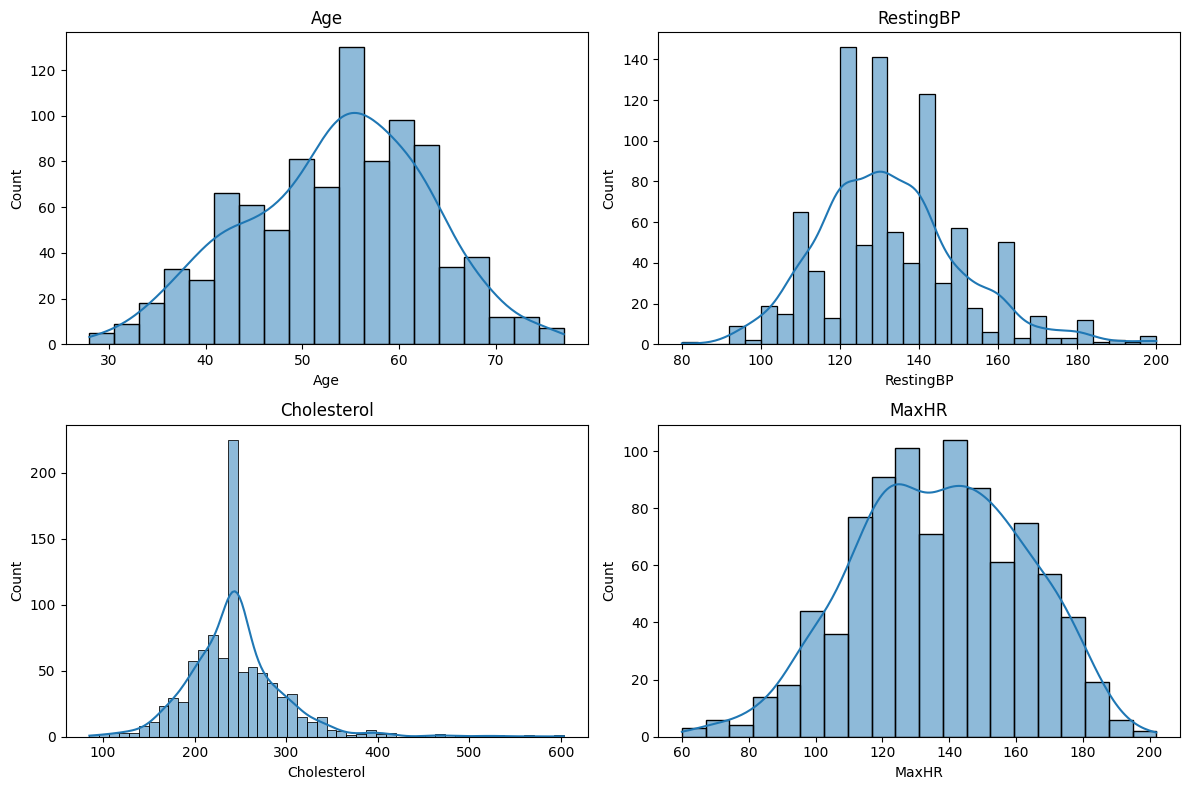

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms(data):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    sns.histplot(data['Age'], kde=True, ax=axes[0,0])
    axes[0,0].set_title('Age')
    sns.histplot(data['RestingBP'], kde=True, ax=axes[0,1])
    axes[0,1].set_title('RestingBP')
    sns.histplot(data['Cholesterol'], kde=True, ax=axes[1,0])
    axes[1,0].set_title('Cholesterol')
    sns.histplot(data['MaxHR'], kde=True, ax=axes[1,1])
    axes[1,1].set_title('MaxHR')
    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [ ]:
df_encoded = pd.get_dummies(df, columns=categorical_cols)
print("Encoded Shape:", df_encoded.shape)
print("\nFirst 5 rows of encoded df:")
print(df_encoded.head())

Encoded Shape: (918, 21)

First 5 rows of encoded df:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_